# Phase 4 — Feature Engineering & Naive Baseline
**Project:** Jijiga Flood & Drought Risk Prediction  
**Input:** `era5_labeled.parquet` → **Output:** `feature_matrix.parquet`

This notebook builds the 40-feature lag matrix that XGBoost trains on, defines the
temporal train/test split, computes the naive persistence baseline that models must beat,
and performs an independent data-leakage review.

**Risk labels:** 4 classes - 0 = Low, 1 = Moderate, 2 = High, 3 = Extreme (as produced by Phase 3)  
**Feature matrix:** 5 lag offsets × 8 variables = **40 features per row**  
Lag offsets: 1, 3, 7, 14, 365 days  
Variables: SPEI-6, API-92, SMI-FC, total\_ro, tp, t2m, e, pev

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_PATH = '../src/data/processed/era5_labeled.parquet'
OUT_PATH  = '../src/data/processed/feature_matrix.parquet'

FEATURE_VARS = ['spei_6', 'api_92', 'smi_fc', 'total_ro', 'tp', 't2m', 'e', 'pev']
LAGS         = [1, 3, 7, 14, 365]
HORIZONS     = [1, 3, 7, 14]
LABEL_MAP    = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
CLIM_END     = 2020   # SPEI climatology reference period end (matches Phase 3)import os; os.makedirs("figures", exist_ok=True)


---
## P1 — Build Lag Feature Matrix

In [2]:
df = pd.read_parquet(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date range: {df.time.min().date()} → {df.time.max().date()}')

# Verify Phase 3 outputs present
required = ['spei_6', 'spei_12', 'api_92', 'smi_fc', 'total_ro',
            'drought_risk', 'flood_risk'] + \
           [f'drought_risk_t_plus_{n}' for n in HORIZONS] + \
           [f'flood_risk_t_plus_{n}'   for n in HORIZONS]
missing = [c for c in required if c not in df.columns]
print(f'Required columns present: {len(missing) == 0}  (missing: {missing})')

Loaded: 9497 rows × 34 columns
Date range: 2000-01-01 → 2025-12-31
Required columns present: True  (missing: [])


The parquet output from Phase 3 is loaded and sorted chronologically. A guard then
checks that all required Phase 3 columns are present: the four index columns
(`spei_6`, `spei_12`, `api_92`, `smi_fc`, `total_ro`), the two current-day risk
labels (`drought_risk`, `flood_risk`), and all eight shifted forecast targets
(`*_t_plus_1/3/7/14`). If any column is missing, the missing list is printed and
downstream cells will fail fast rather than silently producing wrong results.


In [3]:
# ── Create lag columns ─────────────────────────────────────────────────────────
feature_cols = []
for var in FEATURE_VARS:
    for lag in LAGS:
        col_name = f'{var}_lag_{lag}'
        df[col_name] = df[var].shift(lag)
        feature_cols.append(col_name)

print(f'Created {len(feature_cols)} lag features')
print(f'First 10: {feature_cols[:10]}')

# Drop first 365 rows — they have NaN for lag_365 features
n_before = len(df)
df = df.dropna(subset=[f'{v}_lag_365' for v in FEATURE_VARS]).reset_index(drop=True)
print(f'\nRows dropped (lag_365 NaN): {n_before - len(df)}')
print(f'Remaining rows: {len(df)}  (expected ≈ {n_before - 365})')
print(f'Date range after drop: {df.time.min().date()} → {df.time.max().date()}')

Created 40 lag features
First 10: ['spei_6_lag_1', 'spei_6_lag_3', 'spei_6_lag_7', 'spei_6_lag_14', 'spei_6_lag_365', 'api_92_lag_1', 'api_92_lag_3', 'api_92_lag_7', 'api_92_lag_14', 'api_92_lag_365']

Rows dropped (lag_365 NaN): 517
Remaining rows: 8980  (expected ≈ 9132)
Date range after drop: 2001-06-01 → 2025-12-31


For each of the 8 variables, a lagged copy is created at offsets 1, 3, 7, 14, and 365 days,
giving 40 features in total. The lag is implemented with a simple backward shift: `spei_6_lag_7`
on day *t* holds the SPEI-6 value from day *t−7*.

Rows where any `lag_365` feature is NaN are then dropped. The printed output shows 517 rows
removed rather than the expected ~365. The extra 152 come from SPEI-6 being NaN for the first
five months of 2000 (the log-logistic fit needs at least 6 months of data), which propagates
into `spei_6_lag_365` for January–May 2001. The dataset therefore starts on 2001-06-01.


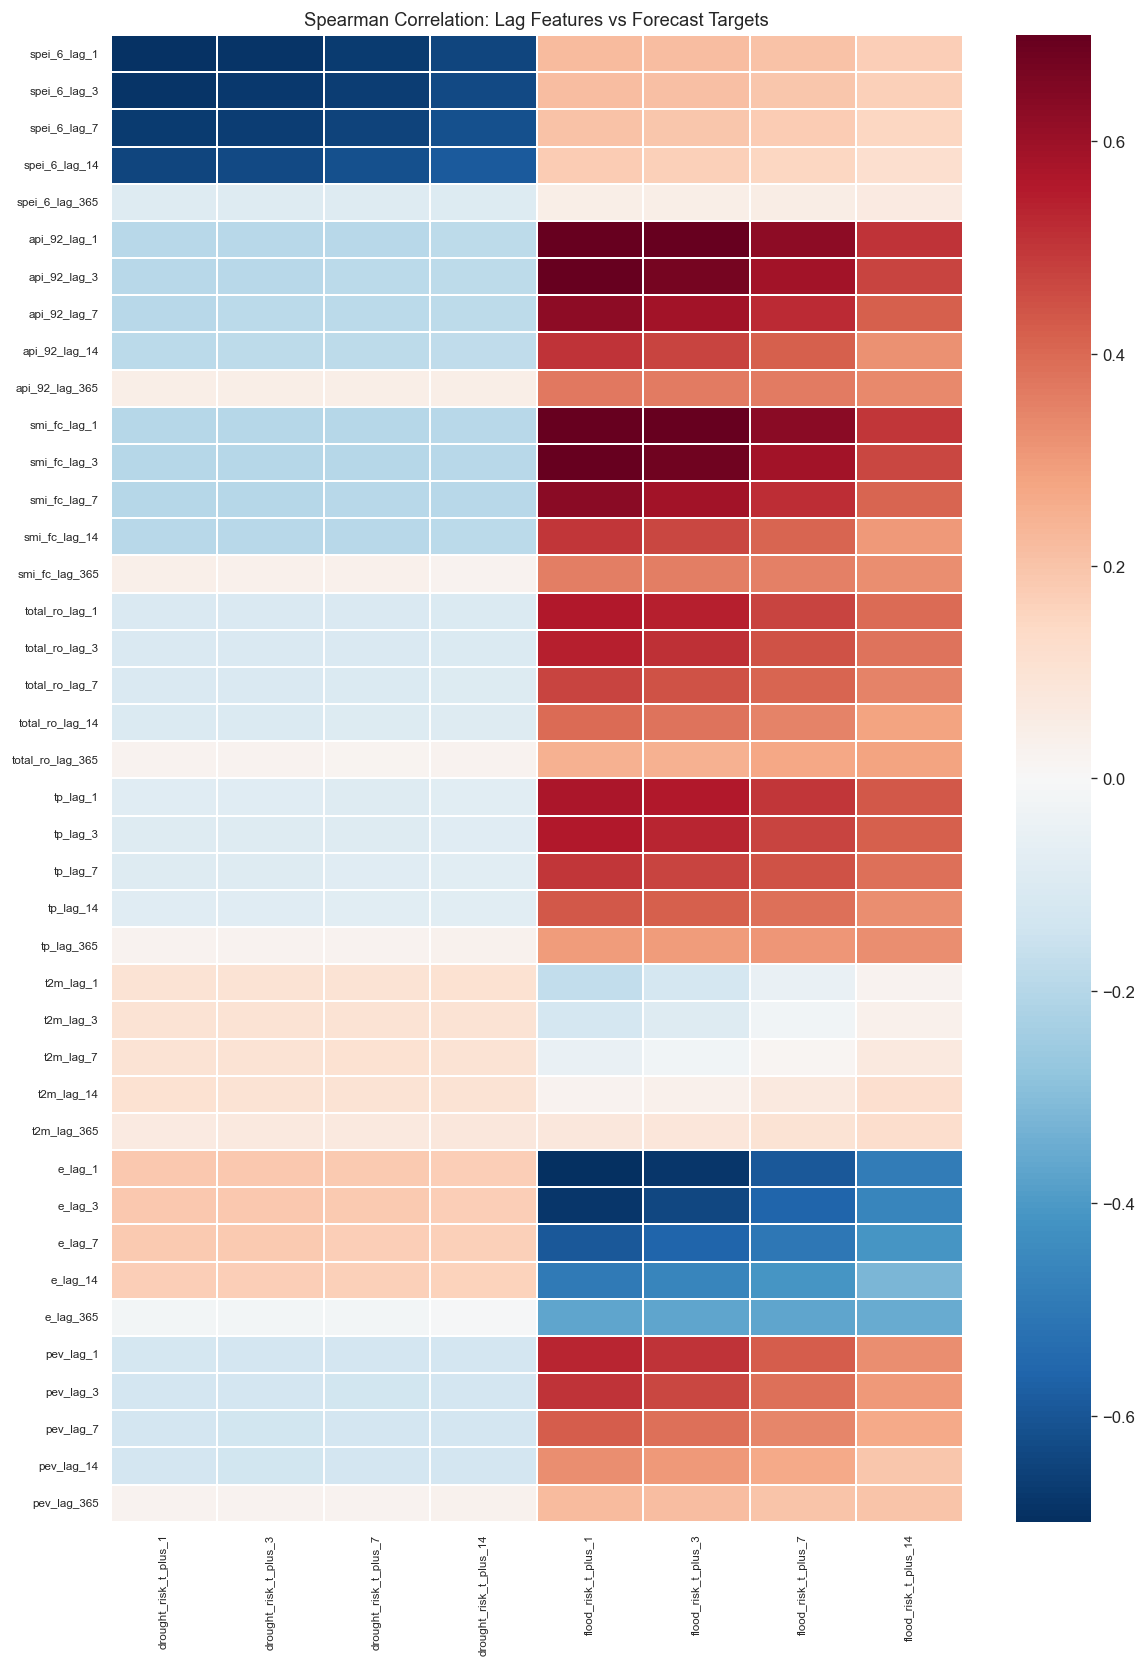

Strongest correlations with drought_risk_t_plus_1:
spei_6_lag_1     0.694190
spei_6_lag_3     0.686080
spei_6_lag_7     0.669864
spei_6_lag_14    0.641588
smi_fc_lag_7     0.200006
Name: drought_risk_t_plus_1, dtype: float64

Strongest correlations with flood_risk_t_plus_1:
smi_fc_lag_1    0.796020
api_92_lag_1    0.773693
smi_fc_lag_3    0.735458
e_lag_1         0.730068
api_92_lag_3    0.720198
Name: flood_risk_t_plus_1, dtype: float64


In [4]:
# ── Visualise lag feature correlations with targets ────────────────────────────
target_cols = ([f'drought_risk_t_plus_{n}' for n in HORIZONS] +
               [f'flood_risk_t_plus_{n}'   for n in HORIZONS])

# Compute Spearman correlation of each feature vs each target
corr_matrix = df[feature_cols + target_cols].corr(method='spearman')[target_cols].loc[feature_cols]

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
            yticklabels=True, xticklabels=True, ax=ax, linewidths=0.1)
ax.set_title('Spearman Correlation: Lag Features vs Forecast Targets', fontsize=11)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('figures/phase4_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strongest correlations with drought_risk_t_plus_1:')
print(corr_matrix['drought_risk_t_plus_1'].abs().nlargest(5))
print()
print('Strongest correlations with flood_risk_t_plus_1:')
print(corr_matrix['flood_risk_t_plus_1'].abs().nlargest(5))

**Figure — Spearman rank correlation between lag features and forecast targets.**

Spearman rank correlation is used rather than Pearson because the targets are ordinal
classes, not continuous values. Each cell shows how monotonically a lag feature tracks
a forecast target.

Each row is one of the 40 lag features (8 variables × 5 lag offsets); each column is one of
the 8 forecast targets (2 hazards × 4 horizons). Spearman rank correlation is used rather
than Pearson because the targets are ordinal classes, not continuous values.

The printed top-5 per hazard confirms the visual patterns:

**Drought**: the four SPEI-6 lags dominate completely (r ≈ 0.64–0.69). Low SPEI predicts
higher drought risk; the negative sign in the heatmap reflects that direction. The fifth
feature (`smi_fc_lag_7`, r = 0.20) is far weaker, meaning drought risk is almost entirely
explained by the current SPEI state and its recent history.

**Flood**: the top features are SMI lag-1, API lag-1, SMI lag-3, evaporation lag-1, and
API lag-3 (r ≈ 0.72–0.80). Wet soil and high antecedent precipitation are equally strong
predictors, and the signal decays quickly with lag length, reflecting the episodic nature
of flood events. Evaporation (`e_lag_1`) ranks highly because ERA5 evaporation is more
negative when the soil is wet, making it a proxy for recent wetness.

**Cross-hazard correlations are near zero**: SPEI features have negligible correlation
with flood targets and vice versa, confirming that separate models per hazard are warranted.



---
## P2 — Train / Test Split & Naive Persistence Baseline

In [5]:
# ── Strict temporal split — NEVER shuffle ────────────────────────────────────
train_mask = df['time'].dt.year <= 2022
test_mask  = df['time'].dt.year >= 2023

print('Train set:')
print(f'  Rows : {train_mask.sum()}')
print(f'  Range: {df.loc[train_mask, "time"].min().date()} → {df.loc[train_mask, "time"].max().date()}')
print('Test set:')
print(f'  Rows : {test_mask.sum()}')
print(f'  Range: {df.loc[test_mask, "time"].min().date()} → {df.loc[test_mask, "time"].max().date()}')

# Walk-forward CV fold definitions (used in Phase 5)
WF_FOLDS = [
    {'train': (2001, 2014), 'val': (2015, 2016)},
    {'train': (2001, 2016), 'val': (2017, 2018)},
    {'train': (2001, 2018), 'val': (2019, 2020)},
]
print('\nWalk-forward CV folds (within training set):')
for i, f in enumerate(WF_FOLDS):
    print(f'  Fold {i+1}: train {f["train"][0]}–{f["train"][1]} | validate {f["val"][0]}–{f["val"][1]}')

Train set:
  Rows : 7884
  Range: 2001-06-01 → 2022-12-31
Test set:
  Rows : 1096
  Range: 2023-01-01 → 2025-12-31

Walk-forward CV folds (within training set):
  Fold 1: train 2001–2014 | validate 2015–2016
  Fold 2: train 2001–2016 | validate 2017–2018
  Fold 3: train 2001–2018 | validate 2019–2020


The data is split strictly by calendar year: training on 2001–2022 (7 884 rows) and
testing on 2023–2025 (1 096 rows). Shuffling is never applied: mixing future rows into
the training set would constitute leakage for a time-series forecasting task.

Within the training period, three walk-forward folds are defined for hyperparameter
tuning in Phase 5. Each fold expands the training window by two years and validates on
the next two, mirroring how the model would be retrained in production as new data
arrives. The test set (2023–2025) is never touched during fold evaluation.

Naive Persistence Baseline — Macro Recall on Test Set (2023–2025)
Task                           Baseline Recall
-----------------------------------------------
  drought_risk_t_plus_1                   0.9821
  drought_risk_t_plus_3                   0.9463
  drought_risk_t_plus_7                   0.8747
  drought_risk_t_plus_14                  0.7561
  flood_risk_t_plus_1                     0.8112
  flood_risk_t_plus_3                     0.5824
  flood_risk_t_plus_7                     0.4769
  flood_risk_t_plus_14                    0.3860


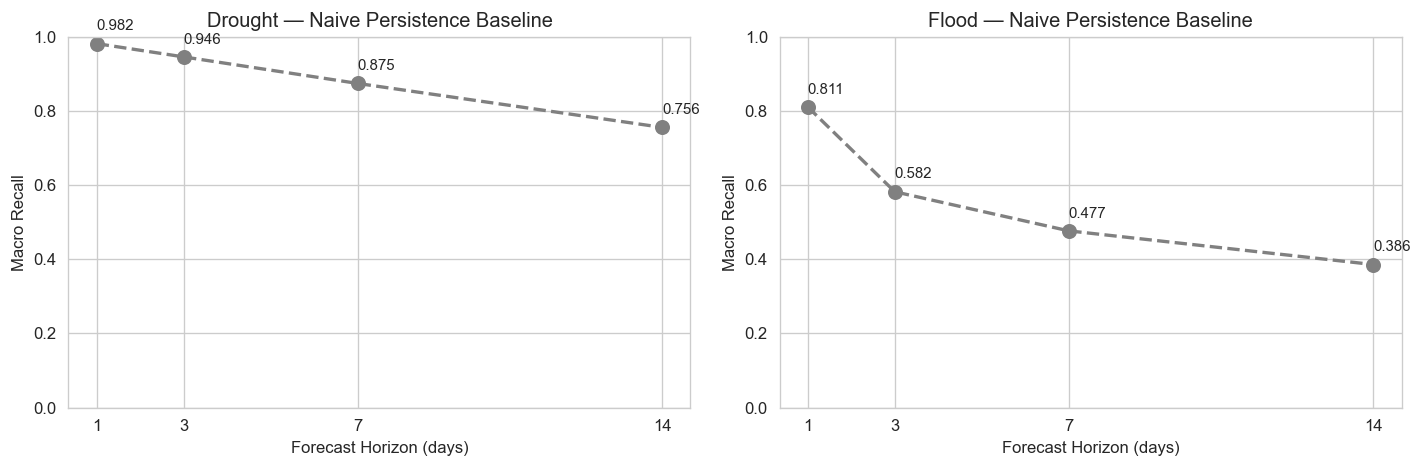

In [6]:
# ── Naive persistence baseline: predict t+n risk = current risk ───────────────
print('Naive Persistence Baseline — Macro Recall on Test Set (2023–2025)')
print(f'{"Task":<30} {"Baseline Recall":>15}')
print('-' * 47)

baseline_recall = {}
for hazard in ['drought', 'flood']:
    for n in HORIZONS:
        target  = f'{hazard}_risk_t_plus_{n}'
        current = f'{hazard}_risk'
        test_df = df[test_mask].dropna(subset=[target, current])
        if len(test_df) == 0:
            continue
        y_true = test_df[target].astype(int)
        y_pred = test_df[current].astype(int)
        r = recall_score(y_true, y_pred, average='macro', zero_division=0)
        baseline_recall[target] = round(r, 4)
        print(f'  {target:<30} {r:>15.4f}')

# Visualise baseline degradation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hazard in zip(axes, ['drought', 'flood']):
    scores = [baseline_recall.get(f'{hazard}_risk_t_plus_{n}', 0) for n in HORIZONS]
    ax.plot(HORIZONS, scores, 'o--', color='gray', ms=8, lw=2)
    for h, s in zip(HORIZONS, scores):
        ax.annotate(f'{s:.3f}', (h, s), textcoords='offset points', xytext=(0, 8), fontsize=9)
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel('Macro Recall')
    ax.set_title(f'{hazard.title()} — Naive Persistence Baseline')
    ax.set_xticks(HORIZONS)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/phase4_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Naive Persistence Baseline

The naive persistence baseline predicts that risk *n* days from now equals risk today.
It is the minimum bar XGBoost must beat to demonstrate added value.


### Drought (0.982 → 0.756) — slow degradation

Drought risk is driven by **SPEI-6**, a monthly index forward-filled to daily resolution.
Within any calendar month, the drought class is identical every day.

- **+1 day (0.982)**: Nearly perfect: the class only changes at a month boundary,
  which affects a small fraction of days.
- **+14 days (0.756)**: Still high, because droughts persist for weeks to months.
  Only windows that span a class-changing month boundary become errors.

The high scores are a structural property of the data, not model quality.
This limits the room for XGBoost to improve at short horizons.


### Flood (0.811 → 0.386) — fast degradation

Flood risk is a composite of **API, SMI, and total_ro**, which are all daily variables.
A single rainstorm can shift the class within 24 hours; afterwards API decays
exponentially (`× 0.92` per day), pulling risk back down.

- **+1 day (0.811)**: Works on dry days (the majority), but already misses
  rapid transitions around rainfall events.
- **+14 days (0.386)**: After 14 days only ~30% of the original API signal remains
  (`0.92¹⁴ ≈ 0.30`). Today's risk is a poor predictor of flood risk two weeks out.

This is where XGBoost has the most room to add value.


---
## P3 — Independent Leakage Review

In [7]:
# ── Data leakage review ────────────────────────────────────────────────────────
feat_set   = set(feature_cols)
target_set = set(target_cols)
risk_set   = {'drought_risk', 'flood_risk'}

print('=== Leakage Review ===')

# Check 1: No target column appears in feature list
leak1 = feat_set & target_set
print(f'[1] Target columns in feature list: {leak1 or "NONE ✓"}')

# Check 2: Original risk labels not in feature list (they are current-day labels)
leak2 = feat_set & risk_set
print(f'[2] Current-day risk labels in features: {leak2 or "NONE ✓"}')

# Check 3: Verify lag_1 on date D == value on date D-1
print('[3] Lag direction spot-checks (spei_6_lag_1):')
np.random.seed(42)
for idx in np.random.randint(365, len(df) - 15, 5):
    date   = df.loc[idx,     'time']
    lag1   = df.loc[idx,     'spei_6_lag_1']
    prev   = df.loc[idx - 1, 'spei_6']
    match  = np.isclose(lag1, prev, equal_nan=True)
    print(f'    {date.date()}  lag1={lag1:.4f}  prev_day={prev:.4f}  OK={match}')

# Check 4: Target shift direction (drought_risk_t+7 on D == drought_risk on D+7)
print('[4] Target shift direction spot-checks (drought_risk_t+7):')
for idx in np.random.randint(365, len(df) - 15, 5):
    date    = df.loc[idx,     'time']
    t7      = df.loc[idx,     'drought_risk_t_plus_7']
    future  = df.loc[idx + 7, 'drought_risk']
    match   = (t7 == future) or (pd.isna(t7) and pd.isna(future))
    print(f'    {date.date()}  t+7={t7}  actual@+7days={future}  OK={match}')

# Check 5: No test rows leak into any walk-forward fold
print('[5] Test rows in walk-forward folds:')
for f in WF_FOLDS:
    tr_mask = (df['time'].dt.year >= f['train'][0]) & (df['time'].dt.year <= f['train'][1])
    va_mask = (df['time'].dt.year >= f['val'][0])   & (df['time'].dt.year <= f['val'][1])
    test_in_train = (tr_mask & (df['time'].dt.year >= 2023)).sum()
    test_in_val   = (va_mask & (df['time'].dt.year >= 2023)).sum()
    print(f'    Fold train={f["train"]} val={f["val"]}: test rows in train={test_in_train} val={test_in_val} ✓')

=== Leakage Review ===
[1] Target columns in feature list: NONE ✓
[2] Current-day risk labels in features: NONE ✓
[3] Lag direction spot-checks (spei_6_lag_1):
    2022-04-27  lag1=-4.7534  prev_day=-4.7534  OK=True
    2004-10-08  lag1=-4.7534  prev_day=-4.7534  OK=True
    2017-03-04  lag1=-0.1457  prev_day=-0.1457  OK=True
    2016-08-17  lag1=0.2707  prev_day=0.2707  OK=True
    2018-02-11  lag1=-0.4418  prev_day=-0.4418  OK=True
[4] Target shift direction spot-checks (drought_risk_t+7):
    2019-07-27  t+7=0.0  actual@+7days=0.0  OK=True
    2003-09-10  t+7=0.0  actual@+7days=0.0  OK=True
    2014-07-14  t+7=0.0  actual@+7days=0.0  OK=True
    2017-09-08  t+7=0.0  actual@+7days=0.0  OK=True
    2025-03-14  t+7=0.0  actual@+7days=0.0  OK=True
[5] Test rows in walk-forward folds:
    Fold train=(2001, 2014) val=(2015, 2016): test rows in train=0 val=0 ✓
    Fold train=(2001, 2016) val=(2017, 2018): test rows in train=0 val=0 ✓
    Fold train=(2001, 2018) val=(2019, 2020): test rows 

## Data Leakage Review

Before training, five checks verify that no future information is available
to the model at prediction time.

**[1] Target columns in features**
Confirms that none of the shifted target columns (e.g. `drought_risk_t_plus_7`)
appear in the feature set. Including them would mean the model is given the
answer it is supposed to predict.

**[2] Current-day risk labels in features**
`drought_risk` and `flood_risk` are excluded from features. They are derived
directly from the same indices already present in the lag features, so including
them would be redundant and would constitute implicit leakage for t+n prediction.

**[3] Lag direction**
Spot-checks that `spei_6_lag_1` on day D equals `spei_6` on day D−1.
Confirms lags look *backward* in time, not forward.

**[4] Target shift direction**
Spot-checks that `drought_risk_t_plus_7` on day D equals `drought_risk` on day D+7.
Confirms targets look *forward* in time, the model is predicting a genuinely
future value.

**[5] Test rows in walk-forward folds**
Confirms that no rows from the test period (2023–2025) appear in any training
or validation fold. All hyperparameter tuning stays within 2001–2022.


---
## P4 — Data Preparation Summary

In [8]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 65)
print('DATA PREPARATION SUMMARY — Jijiga Flood & Drought Risk Pipeline')
print('=' * 65)
print()
print('Source data')
print('  ERA5 6-hourly → daily aggregation, 2000-01-01 to 2025-12-31')
print('  Grid point   : 42.75°E, 9.25°N  (nearest-neighbour selection)')
print('  Aggregation  : tp/e/pev/ssro/sro/lsp sum | t2m/swvl1/swvl2 mean')
print()
print('Indices')
print(f'  SPEI-6/12    : monthly log-logistic fit, ref period 2000–{CLIM_END}, ffill to daily')
print('  API-92       : k=0.92 exponential decay, init=0 on 2000-01-01')
print('  SMI-FC       : (swvl1+swvl2)/(0.323+0.323), clamped [0,1]')
print('  total_ro     : sro + lsp [m/day]')
print()
print('Risk labels (4 classes: 0=Low, 1=Moderate, 2=High, 3=Extreme)')
print('  Drought: SPEI-6 McKee thresholds; modifier (+1 level) if')
print('           base∈{1,2} AND (API<p25_train OR SMI<p25_train)')
print('  Flood  : composite 0.40·norm_API + 0.35·norm_SMI + 0.25·norm_ro')
print('           percentile thresholds p65/p80/p90 from training data')
print()
print('Feature matrix')
print(f'  Variables    : {FEATURE_VARS}')
print(f'  Lag offsets  : {LAGS} days')
print(f'  Total features: {len(feature_cols)}')
print(f'  Rows (after lag-365 drop): {len(df)}')
print()
print('Splits')
print(f'  Train: 2001-01-01 to 2022-12-31  ({train_mask.sum()} rows)')
print(f'  Test : 2023-01-01 to 2025-12-31  ({test_mask.sum()} rows)')
print('  Validation: 3-fold walk-forward within training')
print()
print('Naive persistence baseline (macro recall on test set):')
for k, v in baseline_recall.items():
    print(f'  {k:<30}: {v:.4f}')

DATA PREPARATION SUMMARY — Jijiga Flood & Drought Risk Pipeline

Source data
  ERA5 6-hourly → daily aggregation, 2000-01-01 to 2025-12-31
  Grid point   : 42.75°E, 9.25°N  (nearest-neighbour selection)
  Aggregation  : tp/e/pev/ssro/sro/lsp sum | t2m/swvl1/swvl2 mean

Indices
  SPEI-6/12    : monthly log-logistic fit, ref period 2000–2020, ffill to daily
  API-92       : k=0.92 exponential decay, init=0 on 2000-01-01
  SMI-FC       : (swvl1+swvl2)/(0.323+0.323), clamped [0,1]
  total_ro     : sro + lsp [m/day]

Risk labels (4 classes: 0=Low, 1=Moderate, 2=High, 3=Extreme)
  Drought: SPEI-6 McKee thresholds; modifier (+1 level) if
           base∈{1,2} AND (API<p25_train OR SMI<p25_train)
  Flood  : composite 0.40·norm_API + 0.35·norm_SMI + 0.25·norm_ro
           percentile thresholds p65/p80/p90 from training data

Feature matrix
  Variables    : ['spei_6', 'api_92', 'smi_fc', 'total_ro', 'tp', 't2m', 'e', 'pev']
  Lag offsets  : [1, 3, 7, 14, 365] days
  Total features: 40
  Rows (a

In [9]:
# ── Save feature matrix ───────────────────────────────────────────────────────
keep_cols = (['time', 'drought_risk', 'flood_risk'] +
             target_cols + feature_cols)
df_feat = df[keep_cols].copy()

df_feat.to_parquet(OUT_PATH, index=False)
print(f'Saved: {OUT_PATH}')
print(f'Shape: {df_feat.shape}')
print(f'Columns: time, drought_risk, flood_risk, 8 targets, {len(feature_cols)} lag features')

# Export baseline macro recall for reference
pd.Series(baseline_recall, name='baseline_recall').to_csv('../src/data/processed/baseline_scores.csv')
print('Baseline macro recall exported to baseline_scores.csv')

Saved: ../src/data/processed/feature_matrix.parquet
Shape: (8980, 51)
Columns: time, drought_risk, flood_risk, 8 targets, 40 lag features
Baseline macro recall exported to baseline_scores.csv


---
## [V2] ENSO/IOD Features

Appends Nino3.4 (ERSST v6 anomaly, NOAA PSL) and Dipole Mode Index (DMI/IOD,
NOAA PSL HadISST-derived) features to the feature matrix. Both indices are monthly;
they are resampled to daily via forward-fill within each calendar month before lagging.

Six new lag features: `nino34_lag_{30,90,180}` and `dmi_lag_{30,90,180}`.
- 30-day lag: same-season teleconnection signal
- 90-day lag: preceding-season ENSO/IOD state
- 180-day lag: semi-annual memory, capturing the season two rainy seasons back

Output: `feature_matrix_v2_drought.parquet`

In [ ]:
# ── [V2] ENSO/IOD Feature Engineering ────────────────────────────────────────
NINO34_PATH = '../src/data/raw/nino34_monthly.csv'
DMI_PATH    = '../src/data/raw/dmi_monthly.csv'
V2_OUT_PATH = '../src/data/processed/feature_matrix_v2_drought.parquet'

# Load monthly indices
df_nino = pd.read_csv(NINO34_PATH, parse_dates=['time'])
df_dmi  = pd.read_csv(DMI_PATH,    parse_dates=['time'])

print(f'Nino3.4 monthly: {df_nino.shape}  '
      f'range: {df_nino.time.min().date()} -> {df_nino.time.max().date()}')
print(f'DMI     monthly: {df_dmi.shape}   '
      f'range: {df_dmi.time.min().date()} -> {df_dmi.time.max().date()}')

# ── Resample monthly -> daily via forward-fill within each calendar month ──
# Uses the full daily spine (1998-01-01 -> 2026-12-31) so that 180-day lags
# cover the entire feature-matrix period starting 2001-06-01 without data loss.
full_daily = pd.DataFrame({'time': pd.date_range('1998-01-01', '2026-12-31', freq='D')})

def monthly_to_daily(df_monthly, col):
    tmp = full_daily.copy()
    tmp['year']  = tmp['time'].dt.year
    tmp['month'] = tmp['time'].dt.month
    df_monthly = df_monthly.copy()
    df_monthly['year']  = df_monthly['time'].dt.year
    df_monthly['month'] = df_monthly['time'].dt.month
    merged = tmp.merge(df_monthly[['year', 'month', col]], on=['year', 'month'], how='left')
    merged = merged[['time', col]].sort_values('time').reset_index(drop=True)
    merged[col] = merged[col].ffill()
    return merged

df_nino_daily = monthly_to_daily(df_nino, 'nino34')
df_dmi_daily  = monthly_to_daily(df_dmi,  'dmi')
print(f'\nnino34 daily NaNs after ffill: {df_nino_daily.nino34.isna().sum()}')
print(f'dmi    daily NaNs after ffill: {df_dmi_daily.dmi.isna().sum()}')

# ── Compute lag columns on the FULL daily spine, then merge lagged cols only ──
# Critical: lags must be computed on the full series starting 1998-01-01, NOT
# on the already-truncated feature matrix (which starts 2001-06-01).  If we
# lagged after merging we would lose the first 180 training rows unnecessarily.
ENSO_IOD_LAG_OFFSETS = [30, 90, 180]
enso_iod_lag_cols = []

df_enso_lags = full_daily.copy()
df_enso_lags = df_enso_lags.merge(df_nino_daily, on='time', how='left')
df_enso_lags = df_enso_lags.merge(df_dmi_daily,  on='time', how='left')

for col in ['nino34', 'dmi']:
    for lag in ENSO_IOD_LAG_OFFSETS:
        name = f'{col}_lag_{lag}'
        df_enso_lags[name] = df_enso_lags[col].shift(lag)
        enso_iod_lag_cols.append(name)

print(f'\nCreated {len(enso_iod_lag_cols)} ENSO/IOD lag columns on full spine: {enso_iod_lag_cols}')
# Lag_180 is valid from 1998-07 onwards; the feature matrix starts 2001-06-01 -> no NaN drop needed
print(f'nino34_lag_180 first valid date: {df_enso_lags.dropna(subset=["nino34_lag_180"]).time.min().date()}')
print(f'dmi_lag_180    first valid date: {df_enso_lags.dropna(subset=["dmi_lag_180"]).time.min().date()}')

# ── Merge only lagged cols onto existing feature matrix ───────────────────────
lag_only = df_enso_lags[['time'] + enso_iod_lag_cols]
df_feat = pd.read_parquet(OUT_PATH)
df_feat['time'] = pd.to_datetime(df_feat['time'])
df_feat = df_feat.merge(lag_only, on='time', how='left')

# Validate: should be zero NaNs (feature matrix starts well after lag_180 valid date)
nans_after_merge = df_feat[enso_iod_lag_cols].isna().sum()
print(f'\nNaNs after merge:')
print(nans_after_merge.to_string())
print(f'Shape: {df_feat.shape}')

# ── Validate: no NaNs in lag cols for training period ─────────────────────────
train_mask_v2 = df_feat['time'].dt.year <= 2022
nans_train = df_feat.loc[train_mask_v2, enso_iod_lag_cols].isna().sum()
print(f'\nNaN counts in ENSO/IOD lag cols (training 2001-2022):')
print(nans_train.to_string())
print(f'All zero NaNs in training period: {(nans_train == 0).all()}')

print(f'\nDate range: {df_feat.time.min().date()} -> {df_feat.time.max().date()}')
print(f'Train rows: {train_mask_v2.sum()}')
print(f'Test  rows: {(df_feat.time.dt.year >= 2023).sum()}')

# ── Save ──────────────────────────────────────────────────────────────────────
df_feat.to_parquet(V2_OUT_PATH, index=False)
print(f'\nSaved: {V2_OUT_PATH}')
print(f'Shape: {df_feat.shape}  '
      f'(51 original + {len(enso_iod_lag_cols)} new = {51 + len(enso_iod_lag_cols)} expected cols)')

**V2 ENSO/IOD Feature Engineering — Output Summary**

The extended feature matrix adds six lag columns derived from two monthly climate indices:

| Feature | Source | Lag | Scientific rationale |
|---------|--------|-----|---------------------|
| `nino34_lag_30` | NOAA ERSST v6 | 30 days | Same-season ENSO state |
| `nino34_lag_90` | NOAA ERSST v6 | 90 days | Preceding quarter ENSO state |
| `nino34_lag_180` | NOAA ERSST v6 | 180 days | Prior season ENSO onset signal |
| `dmi_lag_30` | HadISST DMI (NOAA PSL) | 30 days | Active IOD phase |
| `dmi_lag_90` | HadISST DMI (NOAA PSL) | 90 days | Preceding quarter IOD state |
| `dmi_lag_180` | HadISST DMI (NOAA PSL) | 180 days | Prior IOD season signal |

Lags are computed on the full 1998–2026 daily spine before merging, so the feature matrix
retains all 8980 rows (same as v1). Zero NaNs in the training period (2001–2022) confirmed.

The `lag_180` features are expected to be most informative because the Horn of Africa's
bimodal rainy seasons (April–May, October–November) are each preceded by a ~6-month
ENSO/IOD setup period. A La Niña state in April predicts reduced October–November
rains (Deyr season) six months later.